In [1]:
import numpy as np
import pandas as pd
import os
from datetime import datetime
import matplotlib.pyplot as plt

# inputs

In [2]:
#path to save figures
out_path = '/Users/lindsaysummers/Documents/Figures/USGS_benchmark_glacier_data_figures/'

#glacier name (for filenames)
glacier_name = 'Wolverine'

# import and clean data

In [3]:
#import mass balance data
usgs_data = pd.read_csv('/Users/lindsaysummers/Documents/Research/Mass_Balance/USGS/benchmarkGlacier_massBalance/Wolverine/Output_Wolverine_Glacier_Wide_solutions_calibrated.csv')
usgs_data.head()

,Year,Bw,Bs,Ba,ELA,Bw_Date,Ba_Date,Calibration
0,1966,1.62,-2.10,-0.48,1211,1966/05/08,1966/09/17,-0.44
1,1967,1.48,-2.68,-1.20,1318,1967/04/07,1967/09/05,-0.44
2,1968,1.92,-2.72,-0.80,1263,1968/05/10,1968/09/25,-0.44
3,1969,2.28,-1.99,0.29,1166,1969/05/22,1969/09/26,-0.44
4,1970,3.52,-1.69,1.83,982,1970/05/08,1970/09/18,-0.44


In [4]:
#convert year, bw date, and ba date to datetime format
usgs_data['Year'] = pd.to_datetime(usgs_data['Year'], format='%Y')
usgs_data['Bw_Date'] = pd.to_datetime(usgs_data['Bw_Date'], format='%Y/%m/%d')
usgs_data['Ba_Date'] = pd.to_datetime(usgs_data['Ba_Date'], format='%Y/%m/%d')

# plot annual mass balance

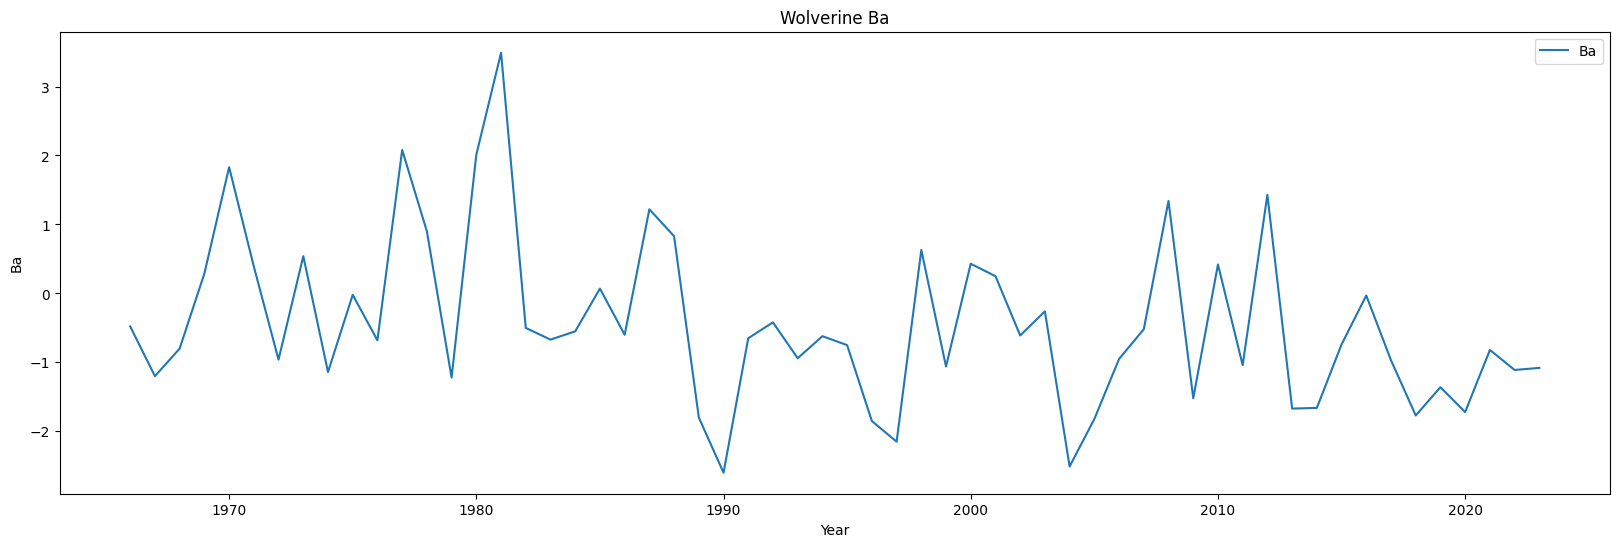

In [5]:
#plot ba
plt.figure(figsize=(20,6))
plt.plot(usgs_data['Year'], usgs_data['Ba'], label='Ba')
plt.xlabel('Year')
plt.ylabel('Ba')
plt.title(glacier_name + ' Ba')
plt.legend()
plt.show()

# plot cumulative mass balance

In [6]:
#calculate cumulative ba
usgs_data['Cum_Ba'] = usgs_data['Ba'].cumsum()

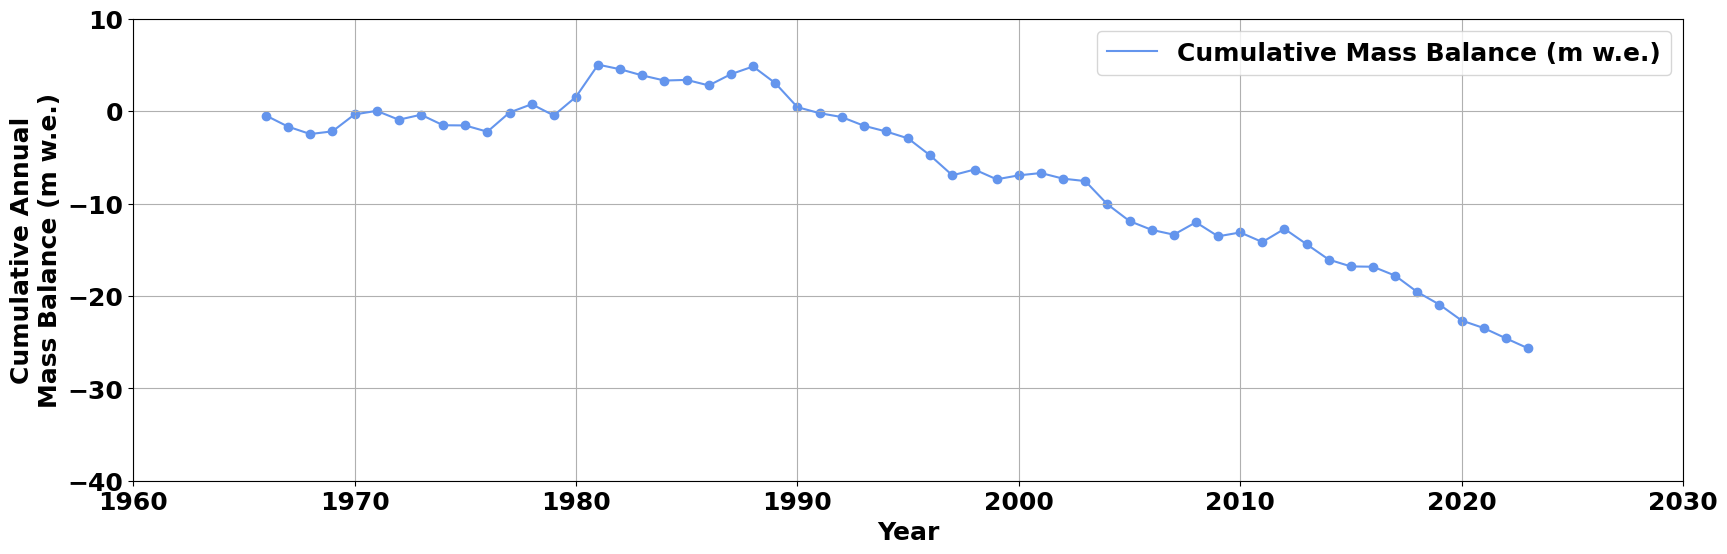

In [7]:
plt.figure(figsize=(20,6))
plt.rcParams['font.size'] = 18
plt.rcParams['font.weight'] = 'bold'

plt.plot(usgs_data['Year'], usgs_data['Cum_Ba'], label='Cumulative Mass Balance (m w.e.)', color='cornflowerblue')
plt.scatter(usgs_data['Year'], usgs_data['Cum_Ba'], color='cornflowerblue')

plt.xlabel('Year', fontweight='bold')
plt.ylabel('Cumulative Annual\nMass Balance (m w.e.)', fontweight='bold')
#plt.title('Wolverine Cumulative Annual Mass Balance')
plt.legend()
plt.grid(True)
plt.ylim(-40,10)
plt.xlim(datetime(1960,1,1), datetime(2030,1,1))

#OPTIONAL: save figure
plt.savefig(out_path + glacier_name + '_cumulative_mass_balance.png')

plt.show()

# plot seasonal mass balance

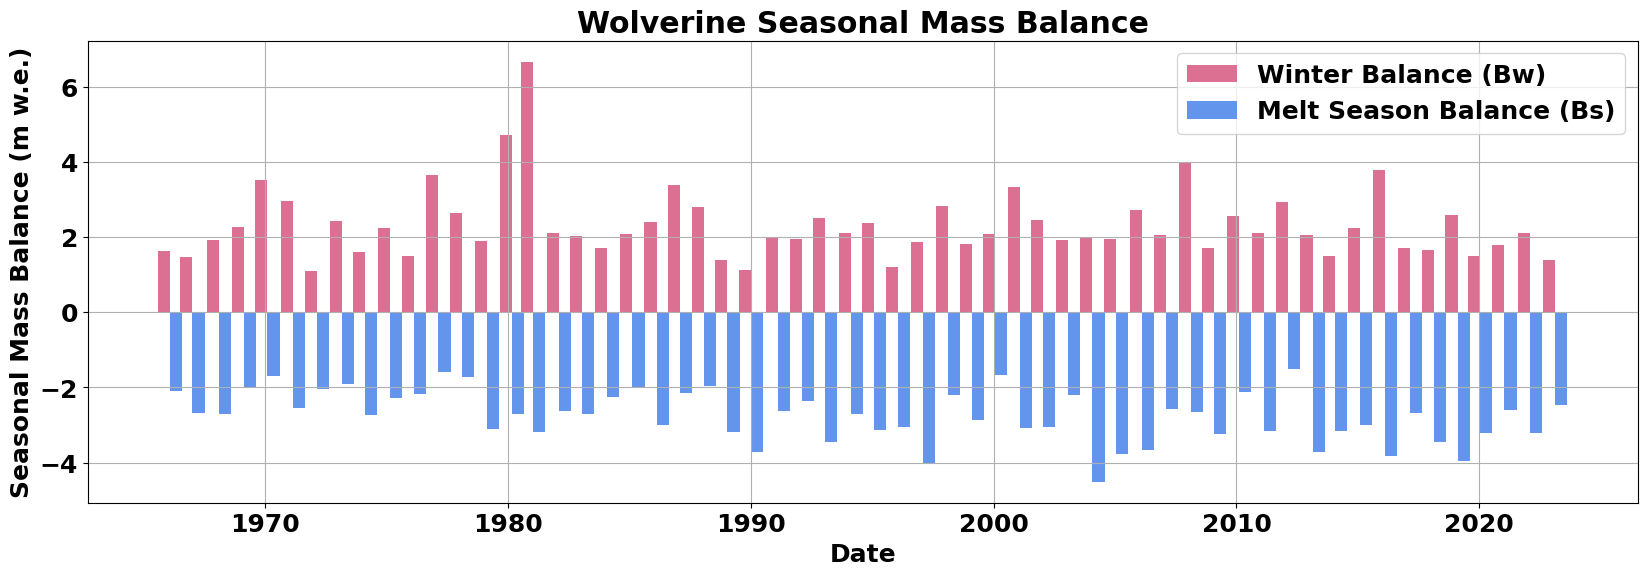

In [8]:
plt.figure(figsize=(20,6))
plt.rcParams['font.size'] = 18
plt.rcParams['font.weight'] = 'bold'

half_year_duration = pd.to_timedelta(365/2, unit='D') # Approximately half a year

# Bw bar: ends at Bw_Date, spans half a year prior
plt.bar(usgs_data['Bw_Date'] - half_year_duration, usgs_data['Bw'],
        width=half_year_duration, label='Winter Balance (Bw)', color='palevioletred')

# Bs bar: starts at Bw_Date, spans half a year forward
plt.bar(usgs_data['Bw_Date'], usgs_data['Bs'],
        width=half_year_duration, label='Melt Season Balance (Bs)', color='cornflowerblue')

plt.xlabel('Date', fontweight='bold')
plt.ylabel('Seasonal Mass Balance (m w.e.)', fontweight='bold')
plt.title(glacier_name + ' Seasonal Mass Balance', fontweight='bold')
plt.grid(True)
plt.legend()

#OPTIONAL: save figure
plt.savefig(out_path + glacier_name + '_seasonal_mass_balance.png')

plt.show()

# plot annual and seasonal mass balance

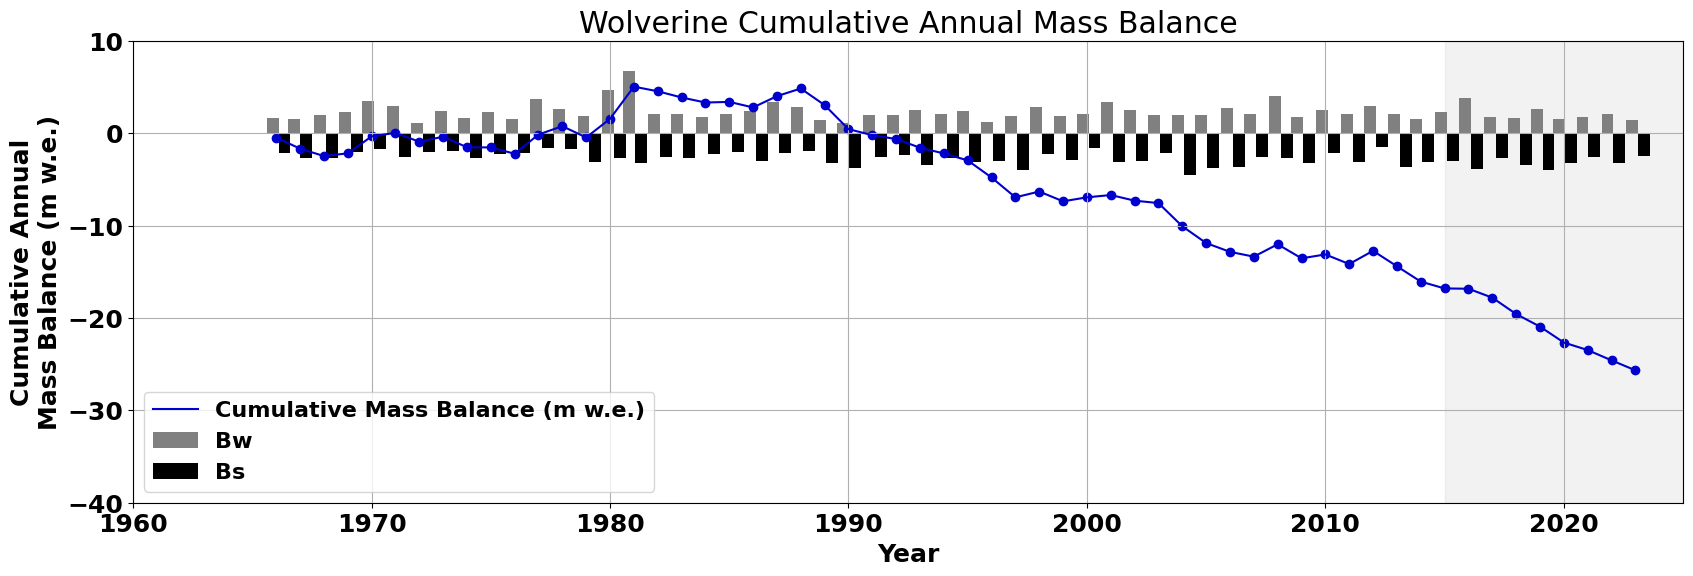

In [9]:
#plot as points in middle of each decade on cumulative ba plot
plt.figure(figsize=(20,6))
plt.rcParams['font.size'] = 18
plt.rcParams['font.weight'] = 'bold'

#gray shading for 2015-2025
plt.axvspan(datetime(2015,1,1), datetime(2025,1,1), color='gray', alpha=0.1)

# Bw bar: ends at Bw_Date, spans half a year prior
plt.bar(usgs_data['Bw_Date'] - half_year_duration, usgs_data['Bw'],
        width=half_year_duration, label='Bw', color='grey')

# Bs bar: starts at Bw_Date, spans half a year forward
plt.bar(usgs_data['Bw_Date'], usgs_data['Bs'],
        width=half_year_duration, label='Bs', color='black')

plt.plot(usgs_data['Year'], usgs_data['Cum_Ba'], label='Cumulative Mass Balance (m w.e.)', color='mediumblue')
plt.scatter(usgs_data['Year'], usgs_data['Cum_Ba'], color='mediumblue')

plt.xlabel('Year', fontweight='bold')
plt.ylabel('Cumulative Annual\nMass Balance (m w.e.)', fontweight='bold')
plt.title(glacier_name + ' Cumulative Annual Mass Balance')
plt.legend(fontsize=16, loc='lower left')
plt.grid(True)
plt.ylim(-40,10)
plt.xlim(datetime(1960,1,1), datetime(2025,1,1))

#OPTIONAL: save figure
plt.savefig(out_path + glacier_name + '_cumulative_annual_and_seasonal_mass_balance.png')

plt.show()

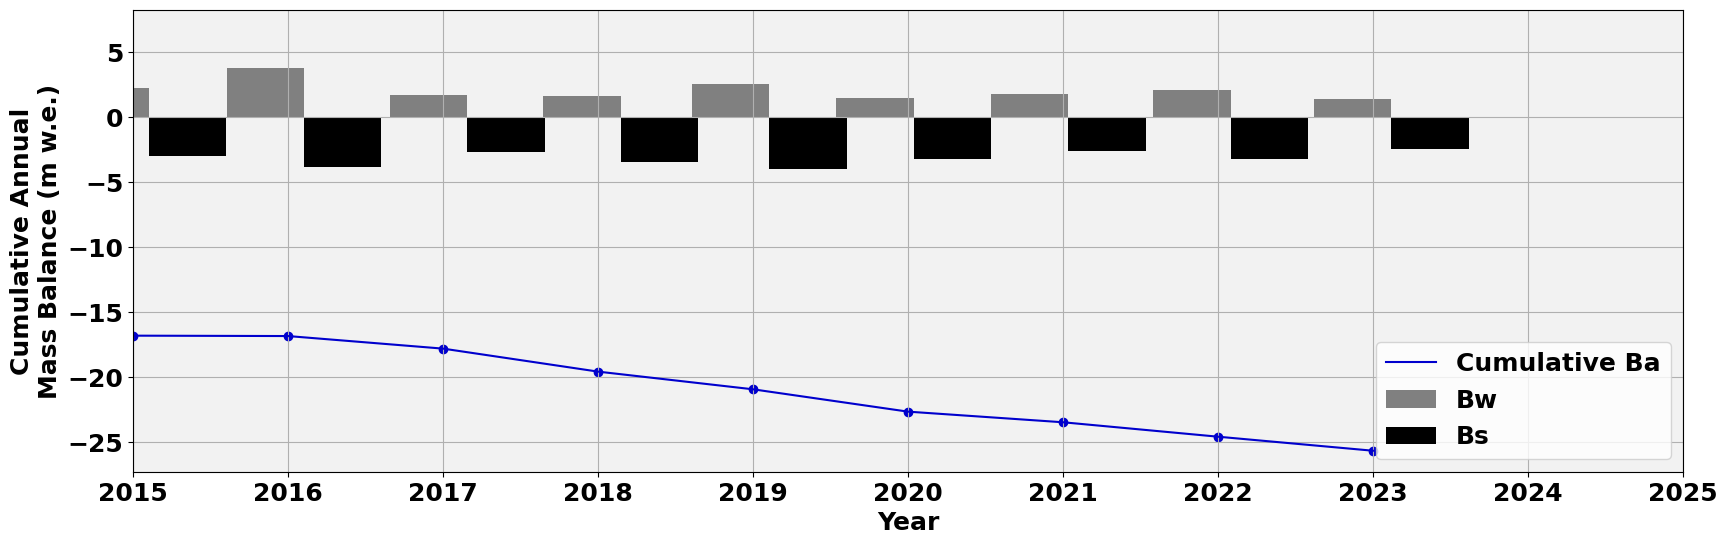

In [10]:
#Plot from 2015-2025
plt.figure(figsize=(20,6))

# Add gray shaded rectangle for 2015-2025
plt.axvspan(datetime(2015,1,1), datetime(2025,1,1), color='gray', alpha=0.1)
plt.plot(usgs_data['Year'], usgs_data['Cum_Ba'], label='Cumulative Ba', color='mediumblue')
plt.scatter(usgs_data['Year'], usgs_data['Cum_Ba'], color='mediumblue')
# Bw (Winter balance) bar: ends at Bw_Date, spans half a year prior
plt.bar(usgs_data['Bw_Date'] - half_year_duration, usgs_data['Bw'],
        width=half_year_duration, label='Bw', color='grey')

# Bs (Melt season balance) bar: starts at Bw_Date, spans half a year forward
plt.bar(usgs_data['Bw_Date'], usgs_data['Bs'],
        width=half_year_duration, label='Bs', color='black')

plt.xlim(datetime(2015,1,1), datetime(2025,1,1))
plt.xlabel('Year', fontweight='bold')
plt.ylabel('Cumulative Annual\nMass Balance (m w.e.)', fontweight='bold')
#plt.title('Wolverine Cumulative Annual Mass Balance 2015-2025')
plt.legend()
plt.grid(True)

#OPTIONAL: save figure
plt.savefig(out_path + glacier_name + '_cumulative_annual_and_seasonal_mass_balance_2015-2025.png')

plt.show()